In [2]:
# !pip install yfinance pmdarima arch statsmodels matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm
from arch import arch_model
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-darkgrid')

In [3]:
soybean_ticker = "ZS=F"
soybean_meal = "ZM=F"
fx_ticker = "THB=X"
start_date = "2023-01-01"
end_date = "2026-05-23"

df_soy = yf.download(soybean_ticker, start=start_date, end=end_date)
df_soy_meal = yf.download(soybean_meal, start=start_date, end=end_date)
df_fx = yf.download(fx_ticker, start=start_date, end=end_date)

soy_values = df_soy['Close'].to_numpy().flatten()
soymeal_values = df_soy_meal['Close'].to_numpy().flatten()
fx_values = df_fx['Close'].to_numpy().flatten()

soy_dates = df_soy.index.to_numpy()
soymeal_dates = df_soy_meal.index.to_numpy()
fx_dates = df_fx.index.to_numpy()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings

In [5]:
def adf_test(series, name=''):
    """Perform Augmented Dickey-Fuller test"""
    result = adfuller(series.dropna())
    
    print(f'\n{"="*60}')
    print(f'ADF Test Results for: {name}')
    print(f'{"="*60}')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print(f"\n✓ Result: STATIONARY (p-value = {result[1]:.6f} < 0.05)")
        print("   → Safe to use for modeling")
    else:
        print(f"\n✗ Result: NON-STATIONARY (p-value = {result[1]:.6f} ≥ 0.05)")
        print("   → Needs transformation before modeling")
    
    return result

def kpss_test(series, name=''):
    """Perform KPSS test"""
    result = kpss(series.dropna(), regression='c', nlags="auto")
    
    print(f'\n{"="*60}')
    print(f'KPSS Test Results for: {name}')
    print(f'{"="*60}')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[3].items():
        print(f'   {key}: {value:.3f}')
    
    if result[1] >= 0.05:
        print(f"\n✓ Result: STATIONARY (p-value = {result[1]:.6f} ≥ 0.05)")
        print("   → Safe to use for modeling")
    else:
        print(f"\n✗ Result: NON-STATIONARY (p-value = {result[1]:.6f} < 0.05)")
        print("   → Needs transformation before modeling")
    
    return result

In [ ]:
adf_test(df_soy['Close'], name='Soybean Close Price')  
kpss_test(df_soy['Close'], name='Soybean Close Price')


ADF Test Results for: Soybean Close Price
ADF Statistic: -2.102611
p-value: 0.243466
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✗ Result: NON-STATIONARY (p-value = 0.243466 ≥ 0.05)
   → Needs transformation before modeling

KPSS Test Results for: Soybean Close Price
KPSS Statistic: 3.213374
p-value: 0.010000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✗ Result: NON-STATIONARY (p-value = 0.010000 < 0.05)
   → Needs transformation before modeling

ADF Test Results for: Soybean Close Price
ADF Statistic: -2.071832
p-value: 0.255991
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✗ Result: NON-STATIONARY (p-value = 0.255991 ≥ 0.05)
   → Needs transformation before modeling

KPSS Test Results for: Soybean Close Price
KPSS Statistic: 3.654933
p-value: 0.010000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✗ Result: NON-STATIONARY (p-value = 0.010000 < 0.05)
   → Needs transformation before modeling


(3.6549329527924845,
 0.01,
 18,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [7]:
adf_test(df_soy_meal['Close'], name='Soybean Close Price')  
kpss_test(df_soy_meal['Close'], name='Soybean Close Price')


ADF Test Results for: Soybean Close Price
ADF Statistic: -2.071832
p-value: 0.255991
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✗ Result: NON-STATIONARY (p-value = 0.255991 ≥ 0.05)
   → Needs transformation before modeling

KPSS Test Results for: Soybean Close Price
KPSS Statistic: 3.654933
p-value: 0.010000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✗ Result: NON-STATIONARY (p-value = 0.010000 < 0.05)
   → Needs transformation before modeling


(3.6549329527924845,
 0.01,
 18,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [18]:
adf_test(df_fx['Close'], name='FX Close Price')  
kpss_test(df_fx['Close'], name='FX Close Price')


ADF Test Results for: FX Close Price
ADF Statistic: -1.449774
p-value: 0.558195
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✗ Result: NON-STATIONARY (p-value = 0.558195 ≥ 0.05)
   → Needs transformation before modeling

KPSS Test Results for: FX Close Price
KPSS Statistic: 2.803985
p-value: 0.010000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✗ Result: NON-STATIONARY (p-value = 0.010000 < 0.05)
   → Needs transformation before modeling


(2.8039849623793556,
 0.01,
 18,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

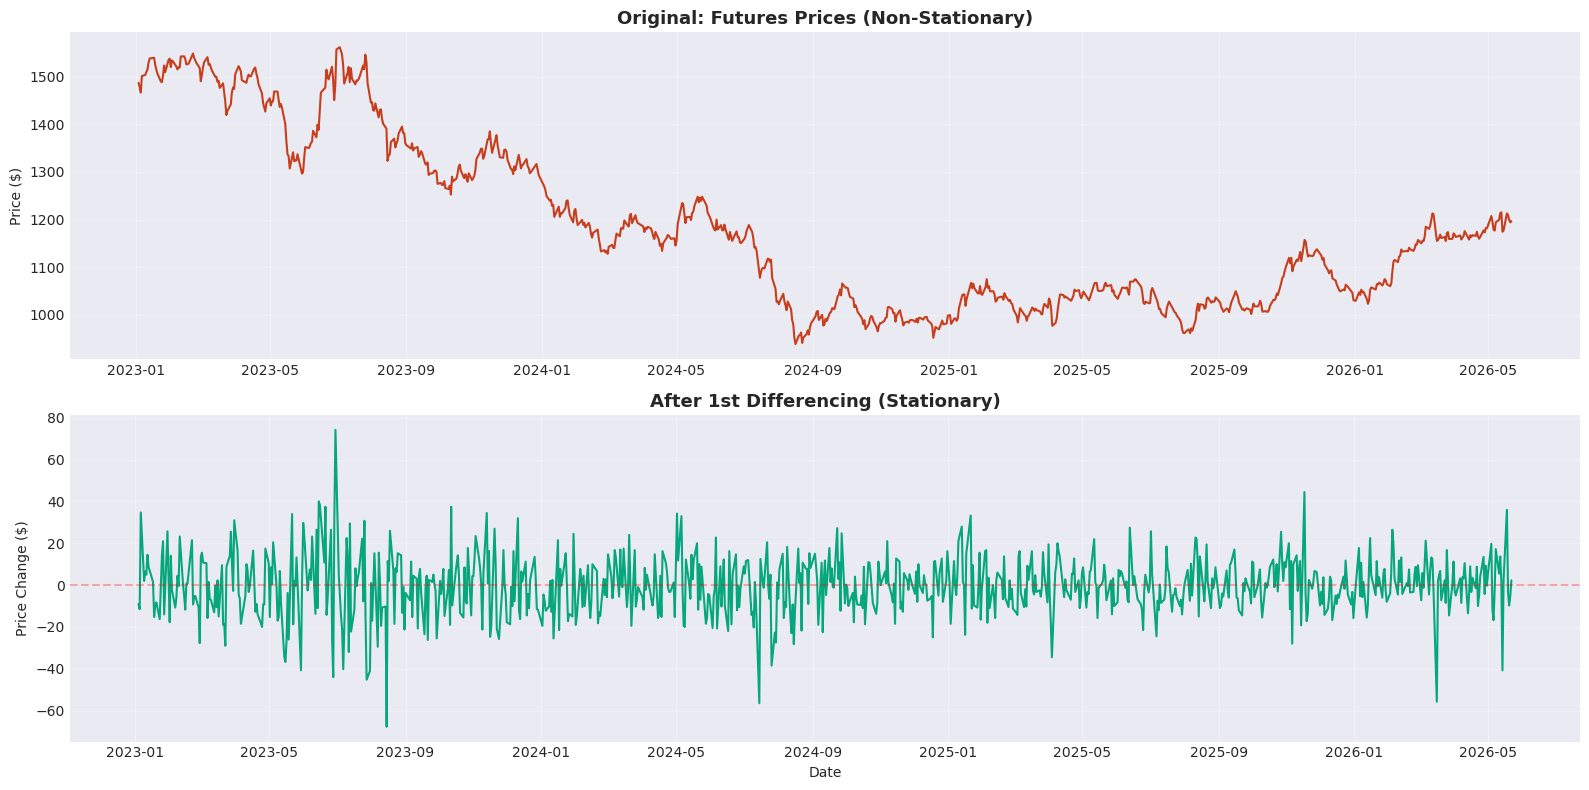


TESTING AFTER DIFFERENCING

ADF Test Results for: First-Differenced Prices
ADF Statistic: -8.289380
p-value: 0.000000
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✓ Result: STATIONARY (p-value = 0.000000 < 0.05)
   → Safe to use for modeling

KPSS Test Results for: First-Differenced Prices
KPSS Statistic: 0.271350
p-value: 0.100000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✓ Result: STATIONARY (p-value = 0.100000 ≥ 0.05)
   → Safe to use for modeling


(0.27135049487885404,
 0.1,
 8,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [21]:
df_soy['soy_values_diff1'] = df_soy['Close'].diff().to_numpy().flatten()
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(soy_dates, soy_values, linewidth=1.5, color='#C73E1D')
axes[0].set_title('Original: Futures Prices (Non-Stationary)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(soy_dates, df_soy['soy_values_diff1'].to_numpy().flatten(), linewidth=1.5, color='#06A77D')
axes[1].set_title('After 1st Differencing (Stationary)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change ($)')
axes[1].set_xlabel('Date')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('differencing_effect.png', dpi=300, bbox_inches='tight')
plt.show()
# Test after differencing
print("\n" + "="*60)
print("TESTING AFTER DIFFERENCING")
print("="*60)
adf_test(df_soy['soy_values_diff1'], 'First-Differenced Prices')
kpss_test(df_soy['soy_values_diff1'], 'First-Differenced Prices')

KeyError: 'soy_values_meal_diff1'

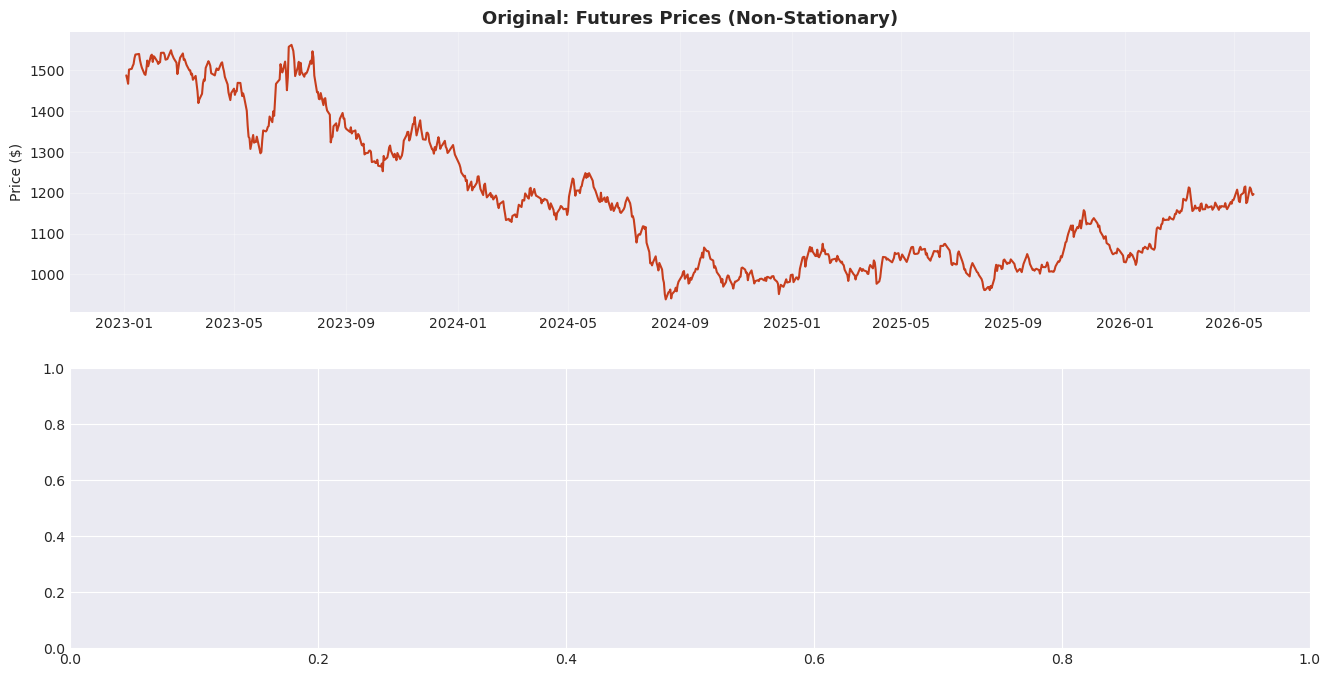

In [ ]:
df_soy_meal['soy_meal_values_diff1'] = df_soy_meal['Close'].diff().to_numpy().flatten()
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(soy_dates, soy_values, linewidth=1.5, color='#C73E1D')
axes[0].set_title('Original: Futures Prices (Non-Stationary)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(soymeal_dates, df_soy_meal['soy_meal_values_diff1'].to_numpy().flatten(), linewidth=1.5, color='#06A77D')
axes[1].set_title('After 1st Differencing (Stationary)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change ($)')
axes[1].set_xlabel('Date')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('differencing_effect.png', dpi=300, bbox_inches='tight')
plt.show()
# Test after differencing
print("\n" + "="*60)
print("TESTING AFTER DIFFERENCING")
print("="*60)
adf_test(df_soy_meal['soy_meal_values_diff1'], 'First-Differenced Prices')
kpss_test(df_soy_meal['soy_meal_values_diff1'], 'First-Differenced Prices')

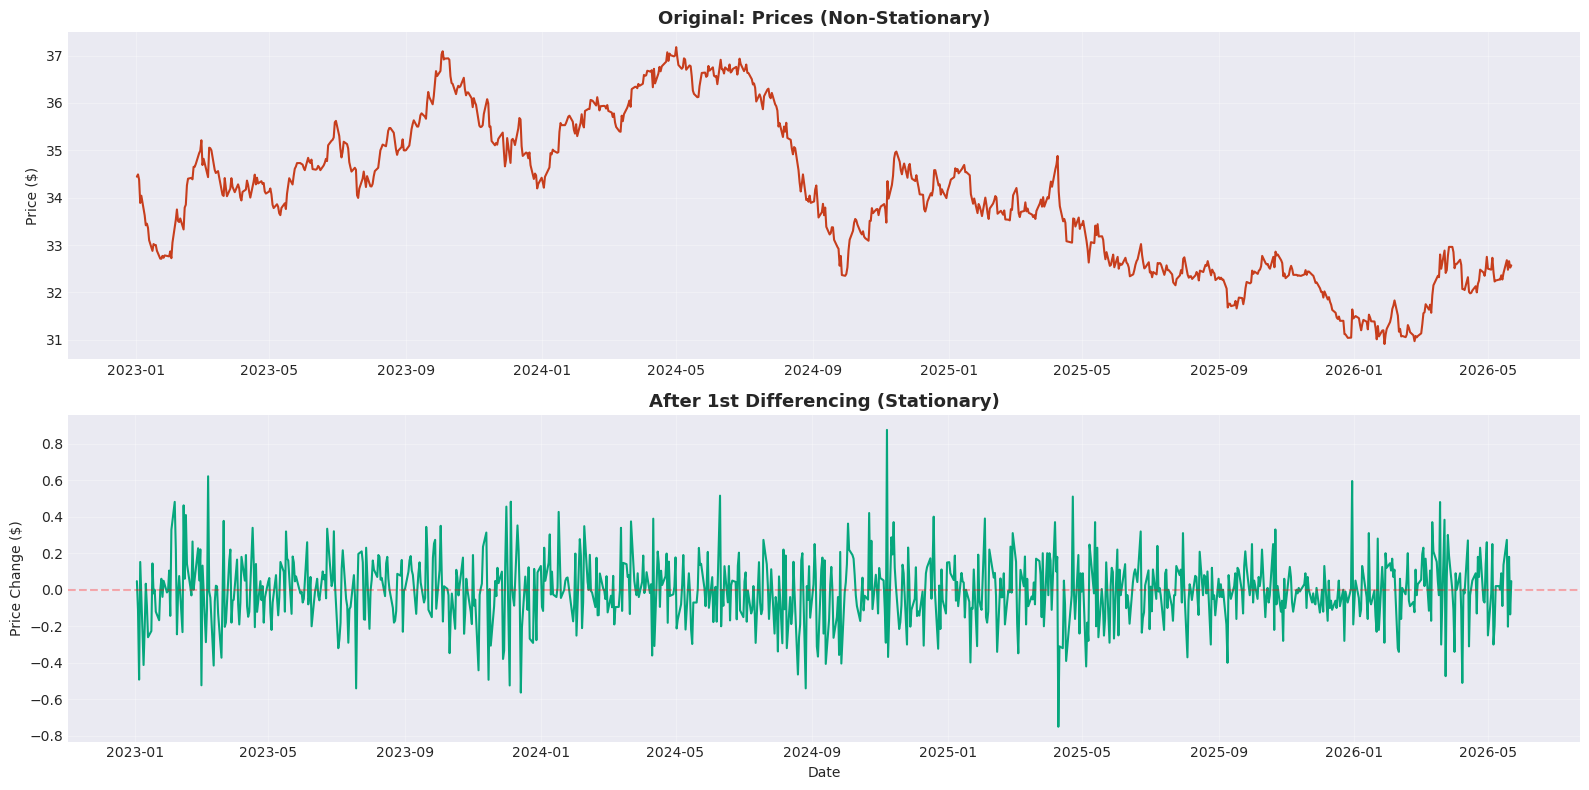


TESTING AFTER DIFFERENCING

ADF Test Results for: First-Differenced Prices
ADF Statistic: -31.647700
p-value: 0.000000
Critical Values:
   1%: -3.438
   5%: -2.865
   10%: -2.569

✓ Result: STATIONARY (p-value = 0.000000 < 0.05)
   → Safe to use for modeling

KPSS Test Results for: First-Differenced Prices
KPSS Statistic: 0.072828
p-value: 0.100000
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✓ Result: STATIONARY (p-value = 0.100000 ≥ 0.05)
   → Safe to use for modeling


(0.07282817141537754,
 0.1,
 1,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [22]:
df_fx['fx_values_diff1'] = df_fx['Close'].diff().to_numpy().flatten()
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(fx_dates, fx_values, linewidth=1.5, color='#C73E1D')
axes[0].set_title('Original: Prices (Non-Stationary)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(fx_dates, df_fx['fx_values_diff1'].to_numpy().flatten(), linewidth=1.5, color='#06A77D')
axes[1].set_title('After 1st Differencing (Stationary)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change ($)')
axes[1].set_xlabel('Date')
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fx_differencing_effect.png', dpi=300, bbox_inches='tight')
plt.show()
# Test after differencing
print("\n" + "="*60)
print("TESTING AFTER DIFFERENCING")
print("="*60)
adf_test(df_fx['fx_values_diff1'], 'First-Differenced Prices')
kpss_test(df_fx['fx_values_diff1'], 'First-Differenced Prices')

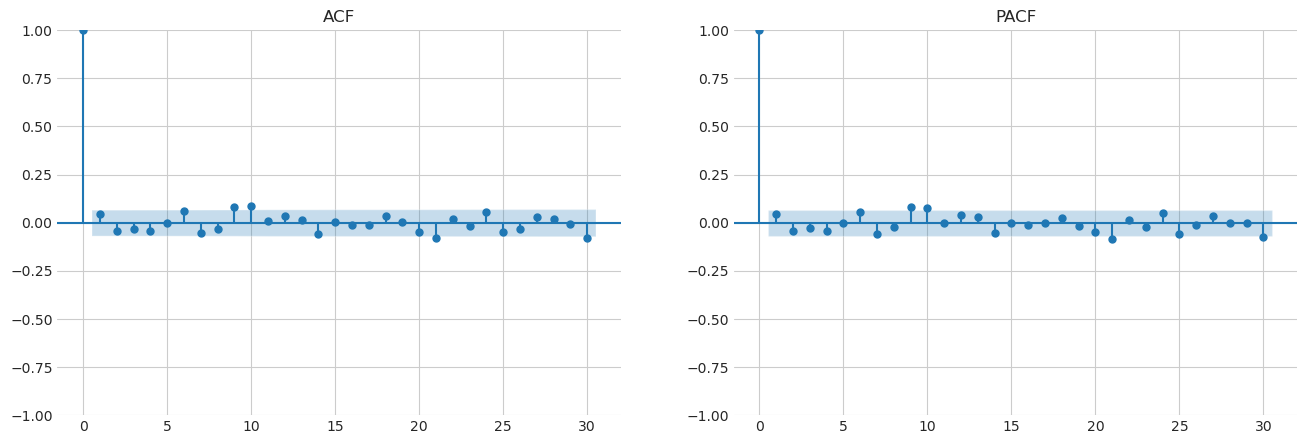

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_soy['soy_values_diff1'].dropna().to_numpy().flatten(), lags=30, ax=axes[0], title="ACF")
plot_pacf(df_soy['soy_values_diff1'].dropna().to_numpy().flatten(), lags=30, ax=axes[1], title="PACF")
plt.show()

In [32]:
auto_model = pm.auto_arima(
    df_soy['Close'], 
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    test='adf',
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

arima_residuals = auto_model.resid()
if auto_model.order[1] > 0:
    arima_residuals = arima_residuals[auto_model.order[1]:]

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=6885.980, Time=0.10 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=6886.227, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=6886.063, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=6884.497, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=6887.291, Time=0.21 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.479 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  851
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -3441.249
Date:                Sun, 31 May 2026   AIC                           6884.497
Time:                        20:27:53   BIC                           6889.243
Sample:                             0   HQIC                          6886.315
                                - 851                                       

In [33]:
rescaled_resid = arima_residuals * 10

garch_model = arch_model(rescaled_resid, vol='Garch', p=1, q=1, rescale=False)
garch_fitted = garch_model.fit(disp='off')

print(garch_fitted.summary())

alpha = garch_fitted.params['alpha[1]']
beta = garch_fitted.params['beta[1]']
alpha_pval = garch_fitted.pvalues['alpha[1]']
beta_pval = garch_fitted.pvalues['beta[1]']

print(f"Alpha: {alpha:.4f} (p-value: {alpha_pval:.4f})")
print(f"Beta: {beta:.4f} (p-value: {beta_pval:.4f})")

persistence = alpha + beta
print(f"\n(Alpha + Beta) = {persistence:.4f}")

if persistence < 1:
    print("Mean Reverting")
    if beta > 0.7:
        print("ตลาดสินค้าเกษตรนี้มีความทรงจำยาวนาน")
else:
    print("ค่าเกิน 1 (โมเดลอาจคำนวณผิดพลาด หรือตลาดกำลังอยู่ในสภาวะวิกฤตที่คุมไม่อยู่)")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -5360.21
Distribution:                  Normal   AIC:                           10728.4
Method:            Maximum Likelihood   BIC:                           10747.4
                                        No. Observations:                  850
Date:                Sun, May 31 2026   Df Residuals:                      849
Time:                        20:32:06   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -2.6174      4.644     -0.564      0.573 [-11.719,  6.48

In [23]:
import seaborn as sns
import numpy as np
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
warnings.filterwarnings('ignore')

PART 7: ADVANCED TIME SERIES METHODS

GARCH Data Generated: 851 observations
Mean return: -0.341657
Volatility (std): 13.863859


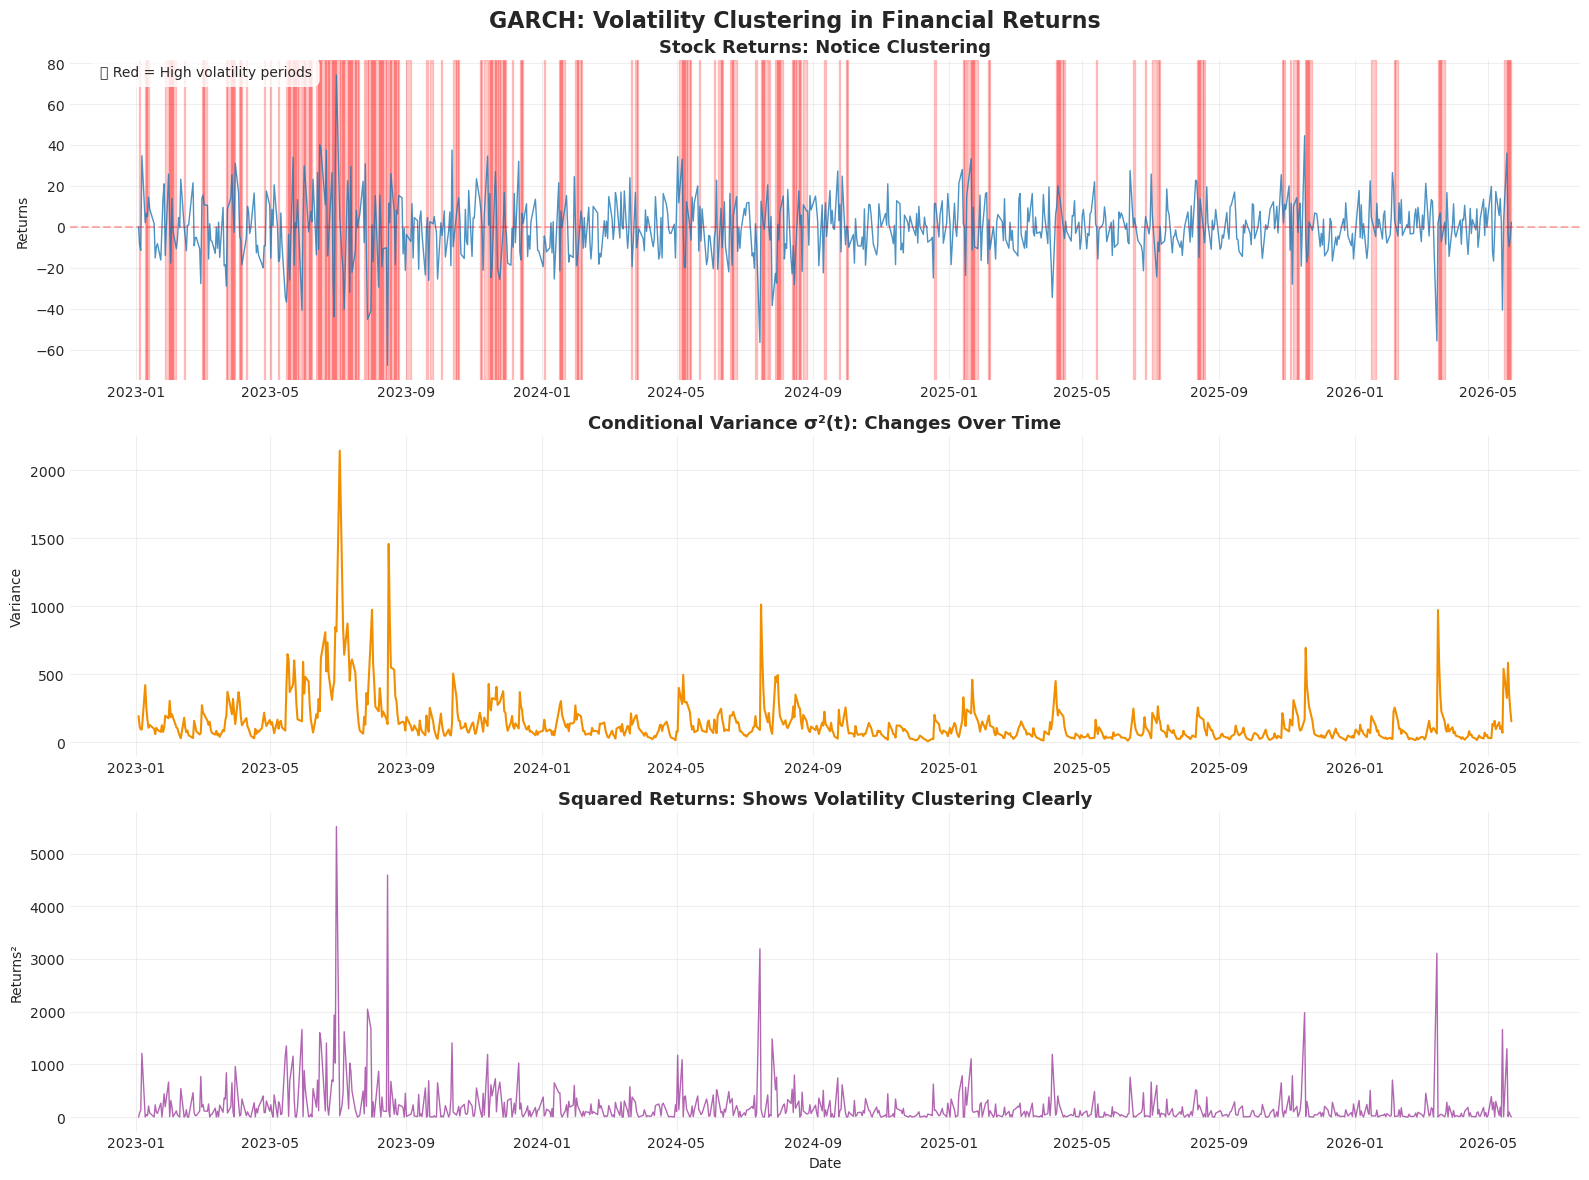


✓ Visualization saved: garch_volatility_clustering.png


In [24]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
np.random.seed(42)
print("="*60)
print("PART 7: ADVANCED TIME SERIES METHODS")
print("="*60)
# Generate data with volatility clustering
returns = df_soy['soy_values_diff1'].fillna(0).to_numpy().flatten()
n = len(returns) # start_date = "2023-01-01" - end_date = "2026-05-23"
omega = 0.1
alpha = 0.3  # ARCH effect
beta = 0.6   # GARCH effect
# Simulate GARCH(1,1)
variance = np.zeros(n)
variance[0] = np.var(returns)

for t in range(1, n):
    # Variance equation
    variance[t] = omega + alpha * returns[t-1]**2 + beta * variance[t-1]
# Create DataFrame
dates = soy_dates
df_garch = pd.DataFrame({
    'returns': returns,
    'variance': variance
}, index=dates)

print(f"\nGARCH Data Generated: {len(df_garch)} observations")
print(f"Mean return: {df_garch['returns'].mean():.6f}")
print(f"Volatility (std): {df_garch['returns'].std():.6f}")
# Visualize volatility clustering
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('GARCH: Volatility Clustering in Financial Returns', 
             fontsize=16, fontweight='bold')
# Returns
axes[0].plot(df_garch.index.to_numpy().flatten(), df_garch['returns'].to_numpy().flatten(), linewidth=1, alpha=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('Stock Returns: Notice Clustering', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Returns')
axes[0].grid(True, alpha=0.3)
# Highlight volatile periods
volatile_periods = df_garch['variance'] > df_garch['variance'].quantile(0.75)
for i in range(len(df_garch)):
    if volatile_periods.iloc[i]:
        axes[0].axvspan(df_garch.index[i], df_garch.index[min(i+1, len(df_garch)-1)], 
                       alpha=0.2, color='red')
axes[0].text(0.02, 0.95, '🔴 Red = High volatility periods', 
            transform=axes[0].transAxes, fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8))
# Conditional variance
axes[1].plot(df_garch.index.to_numpy().flatten(), df_garch['variance'].to_numpy().flatten(), linewidth=1.5, color='#F18F01')
axes[1].set_title('Conditional Variance σ²(t): Changes Over Time', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Variance')
axes[1].grid(True, alpha=0.3)
# Squared returns (to see volatility)
axes[2].plot(df_garch.index.to_numpy().flatten(), df_garch['returns'].to_numpy().flatten()**2, linewidth=1, alpha=0.6, color='purple')
axes[2].set_title('Squared Returns: Shows Volatility Clustering Clearly', 
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Returns²')
axes[2].set_xlabel('Date')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_volatility_clustering.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved: garch_volatility_clustering.png")

In [ ]:
def fit_garch(returns, p=1, q=1):
    """
    Fit GARCH(p,q) model
    
    Parameters:
    -----------
    returns : pd.Series
        Return series
    p : int
        GARCH order
    q : int
        ARCH order
    
    Returns:
    --------
    model_fit : ARCHModelResult
        Fitted GARCH model
    """
    print("\n" + "="*60)
    print(f"FITTING GARCH({p},{q})")
    print("="*60)
    
    # Multiply by 100 for numerical stability
    returns_scaled = returns * 100
    
    # Specify model
    model = arch_model(returns_scaled, vol='Garch', p=p, q=q, rescale=False)
    
    # Fit
    model_fit = model.fit(disp='off')
    
    print("\n✅ Model fitted successfully!")
    print("\nParameter Estimates:")
    print(model_fit.params)
    
    return model_fit

In [ ]:
# Fit GARCH(1,1)
garch_fit = fit_garch(df_garch['returns'], p=1, q=1)
# Model summary
print("\n" + "="*60)
print("FULL MODEL SUMMARY")
print("="*60)
print(garch_fit.summary())
# Extract conditional volatility
conditional_vol = garch_fit.conditional_volatility / 100  # Scale back
# Plot fitted vs actual
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('GARCH Model: Fitted vs Actual Volatility', fontsize=16, fontweight='bold')
axes[0].plot(soy_dates, df_garch['returns'].to_numpy(), label='Returns', 
            linewidth=1, alpha=0.7)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[0].set_title('Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(soy_dates, np.sqrt(df_garch['variance']).to_numpy(), 
            label='True Volatility', linewidth=2, color='red', alpha=0.7)
axes[1].plot(soy_dates, conditional_vol.to_numpy(), 
            label='GARCH Fitted Volatility', linewidth=2, 
            linestyle='--', color='blue', alpha=0.7)
axes[1].set_title('Volatility: True vs Fitted', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility (Std Dev)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('garch_fitted_volatility.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved: garch_fitted_volatility.png")